# difficult_mnist by Yoonhero

본 코드에서는 difficult_mnist 데이터셋 로딩과 기본적인 CNN baseline을 제공합니다.

About dataset
- 이미지 크기 (3x64x64)입니다.
- 3가지 색깔로 이루어진 펜으로 5가지 질감과 색이 다른 종이에 쓰인 숫자를 맞춰야 합니다.
- 숫자는 0-9로 구성되어 있습니다.
- 숫자의 위치는 랜덤하게 설정되었고, 숫자의 크기 도한 랜덤하게 설정되었습니다.

### Download and make Pytorch Dataloader.

Train, Validation을 나눌 필요가 있긴 합니다. 만약 그러신다면 본 라벨은 뒤죽박죽 섞여 있기에 로딩한 데이터셋을 적절히 인덱싱해서 나누어주세요. or train_test_split 코드 활용해보기

p.s. (Tensorflow의 경우는 ds = ds.with_format("tf"))을 사용하면 됩니다.

- 참고: https://huggingface.co/docs/datasets/en/use_with_tensorflow

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from datasets import load_dataset, Features, Array3D, ClassLabel

features = Features({"image": Array3D(shape=(3, 64, 64), dtype='float32'), "label": ClassLabel(names=list(range(10)))}) # To avoid this, you must explicitly use the Array feature type and specify the shape of your tensors:
ds = load_dataset("yoonhero/difficult_mnist_2", num_proc=4, features=features) # download 시간이 조금 소요될 수 있습니다.
device = "mps" # 사용 가능한 accelerator 여부에 따라서 다음을 바꿔줍니다.
ds = ds.with_format("torch", device=device) # https://huggingface.co/docs/datasets/en/use_with_pytorch

In [2]:
row = ds["train"][0]
row["image"].shape, row["image"].dtype

(torch.Size([3, 64, 64]), torch.float32)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 69000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
})


Text(0.5, 1.0, '1')

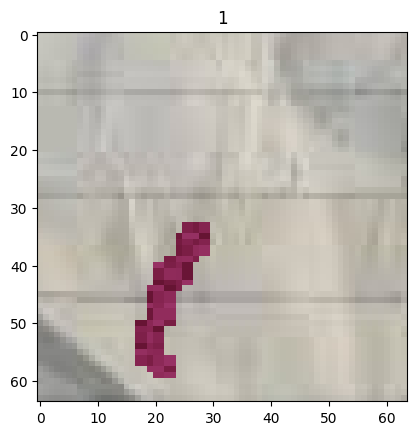

In [3]:
print(ds) # image와 label로 이루어져 있으며 ds["train"][rownum]로 접근할 수 있습니다.
import matplotlib.pyplot as plt
plt.imshow(ds["train"][0]["image"].permute(1, 2, 0).cpu().numpy())
plt.title(ds["train"][0]["label"].item())

In [4]:
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# train_data, val_data = train_test_split(ds["train"], )
batch_size = 256
dataloader = DataLoader(ds["train"], batch_size=batch_size, shuffle=False)

In [5]:
import time

iteration_test = iter(dataloader)
for _ in range(3):
    next(iteration_test) # 0th batch! -> wrap up

durations = []
for _ in range(10):
    start = time.perf_counter()
    second = next(iteration_test)
    end = time.perf_counter()
    durations.append((duration:=end-start))
    print(f"{duration}s by .perf_counter()")

0.02209720899918466s by .perf_counter()
0.01674533400000655s by .perf_counter()
0.017421667000235175s by .perf_counter()
0.01917712499925983s by .perf_counter()
0.018666917001610273s by .perf_counter()
0.017691375000140397s by .perf_counter()
0.01892358300028718s by .perf_counter()
0.01671383299981244s by .perf_counter()
0.0213432919990737s by .perf_counter()
0.016843749999679858s by .perf_counter()


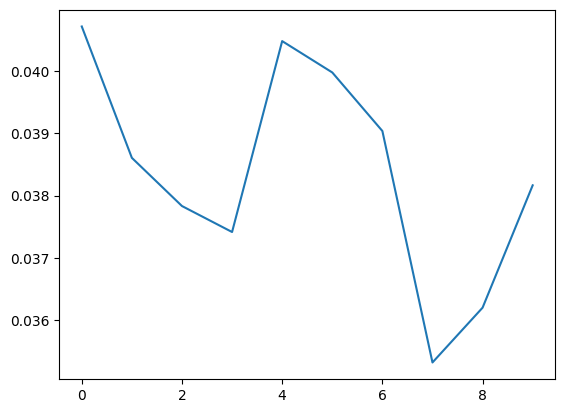

In [6]:
import matplotlib.pyplot as plt

plt.plot(range(10), durations) # before optimization

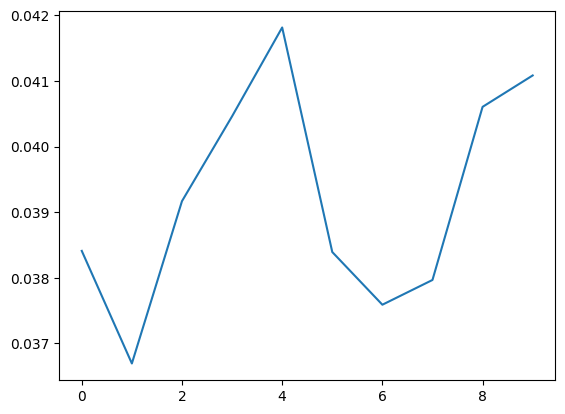

In [7]:
import matplotlib.pyplot as plt

plt.plot(range(10), durations) # after optimization

In [7]:
for batch in dataloader:
    images = batch["image"]
    label = batch["label"]
    print(images.shape, label.shape)
    break

torch.Size([256, 3, 64, 64]) torch.Size([256])


### Baseline Example

간단한 CNN 네트워크 및 학습 코드입니다.

*주의*

너무 간단해서 잘 작동하지 않을거에요..

개선점
- 1x28x28 -> 3x64x64 커진 이미지를 어떻게 처리할까? -> imagenet!(256x256)
- 숫자의 영역에만 attend해서 예측할 수는 없을까? -> https://www.youtube.com/watch?v=ByjaPdWXKJ4 "1:00:20부터"
- 색깔이 아닌 형태에만 집중하고 있을까? -> deeper analysis on CNN feature act visualization!

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SmallNetwork(nn.Module):
    def __init__(self): # 64 -> 32 -> 16 -> 8
        super().__init__()
        self.projection0 = nn.Linear(3*64*64, 512)
        self.projection1 = nn.Linear(512, 10)

        self.act = nn.ReLU()

    def forward(self, x, y=None):
        B = x.size(0)
        x = x.view(B, -1)
        x = self.projection0(x)
        x = self.act(x)
        x = self.projection1(x)
        loss = None
        if y is not None:
            loss = F.cross_entropy(x, y, reduction="mean")
        return x, loss

class ConvBlock(nn.Module):
    def __init__(self, indim, outdim):
        super().__init__()

        self.conv1 = nn.Conv2d(indim, indim*3, (3, 3), stride=1, padding=(1, 1), bias=False)
        self.conv2 = nn.Conv2d(indim*3, outdim, (3, 3), stride=1, padding=(1, 1))
        self.act = nn.ReLU()
        self.norm0 = nn.BatchNorm2d(indim)
        self.norm1 = nn.BatchNorm2d(indim*3)

        self.conv0 = nn.Conv2d(indim, outdim, (1, 1), stride=1)
        #self.conv0.apply(self._init_weights)
        
    def _init_weights(self, module):
        module.weight.data = torch.ones_like(module.weight.data)

    def forward(self, x):
        xx = self.act(self.norm0(x))
        xx = self.act(self.norm1(self.conv1(x)))
        xx = self.conv2(xx)
        x = self.conv0(x)+xx
        return x

class Network(nn.Module):
    def __init__(self): # 64 -> 32 -> 16 -> 8
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)

        self.convblock0 = ConvBlock(3, 16)
        self.convblock1 = ConvBlock(16, 32)
        self.convblock2 = ConvBlock(32, 64) # 64x8x8
        # self.convblock3 = ConvBlock(64, 256)

        self.dropout = nn.Dropout(0.25)

        self.projection0 = nn.Linear(64*8*8, 512)
        self.projection1 = nn.Linear(512, 10)

        self.act = nn.ReLU()

    def forward(self, x, y=None):
        B = x.size(0)
        x = self.pool(self.convblock0(x))
        x = self.pool(self.convblock1(x))
        x = self.pool(self.convblock2(x))
        x = self.act(x)
        # x = self.act(self.convblock3(x))
        x = x.view(B, -1)
        x = self.act(self.projection0(x))
        x = self.dropout(x)
        x = self.projection1(x)
        loss = None
        if y is not None:
            loss = F.cross_entropy(x, y, reduction="mean")
        return x, loss

In [6]:
net = Network().to(device)

net.load_state_dict(torch.load("./tmp/history_20250426-221552/ckp/epoch-9.pkl", weights_only=True)["model"])
# net(next(iter(dataloader))["image"])
lr = 0.0005
optimizer = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=0.01)

In [ ]:
max_epoch = 30

for epoch in range(max_epoch):
    loss_accum = 0
    total_acc = 0
    max_n = 0
    for n, batch in enumerate(tqdm.tqdm(dataloader)):
        images = batch["image"]
        labels = batch["label"]
        if n * batch_size > 60000: # 60000 train / 9000 valitem()
            continue
        else:
            net.train()
            max_n = n+1
        y, loss = net(images, labels)
        loss_accum += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"epoch: {epoch} loss: {loss_accum/(max_n)}")

In [ ]:
import tqdm
import time
from essential import exp_logger
import inspect
start = time.monotonic()
configs = exp_logger.BasicConfig(lr=lr, start=start, model_hp={}, model_script="", optimizer={"weight_decay": 0.01})
run = exp_logger.Logger(exp_logger.OFFLINE, run_name=f"64 channel", configs=configs)

max_epoch = 30

for epoch in range(max_epoch):
    loss_accum = 0
    total_acc = 0
    max_n = 0
    val_items = 0
    for n, batch in enumerate(tqdm.tqdm(dataloader)):
        images = batch["image"]
        labels = batch["label"]
        if n * batch_size > 60000: # 60000 train / 9000 val
            with torch.no_grad():
                net.eval()
                y, _ = net(images)
                total_acc += (y.argmax(-1)==labels).float().sum(0).item()
                val_items += labels.size(0) # B, _, _, _,
                continue
        else:
            net.train()
            max_n = n+1
        y, loss = net(images, labels)
        loss_accum += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    run.log({"train/loss": loss_accum/max_n, "val/acc": total_acc/val_items}, step=epoch)
    run.log_ckp(net, epoch)
    if epoch+1 == max_epoch:
        run.save_ckp(net, optimizer, f"epoch-{epoch}.pkl")

    print(f"epoch: {epoch} loss: {loss_accum/(max_n)} val acc: {total_acc/val_items}")

5


(-0.5, 63.5, 63.5, -0.5)

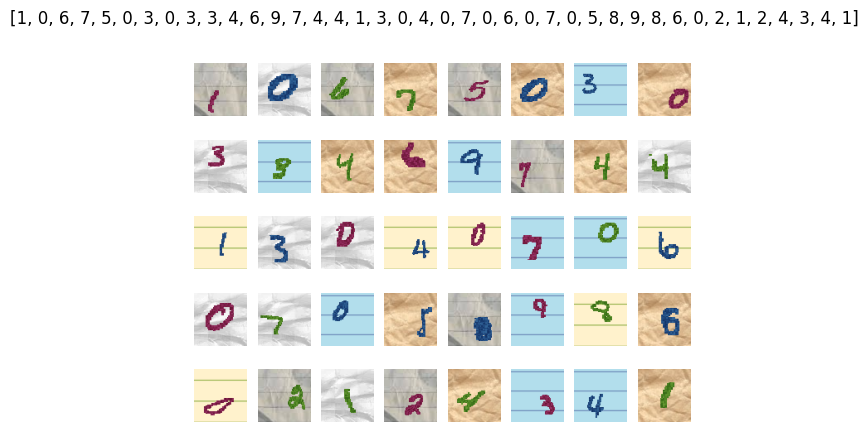

In [8]:
import helpers
from helpers import *

sample = next(iter(dataloader))
images, subtitles = sample["image"][:40], sample["label"][:40].tolist()
show_grid(images, subtitles)
plt.axis("off")

- How it works on 256 filter bandwidth? -> Not so much great here..(too low activation? = dead cells)
- Act Location = Information ---> Way to have a Object Detection!

In [9]:
#_ = plt.hist(weights[-1].view(-1), bins=20, density=True)
# _ = plt.hist(weights[1].view(-1), bins=100, density=True)


tensor(424., device='mps:0')


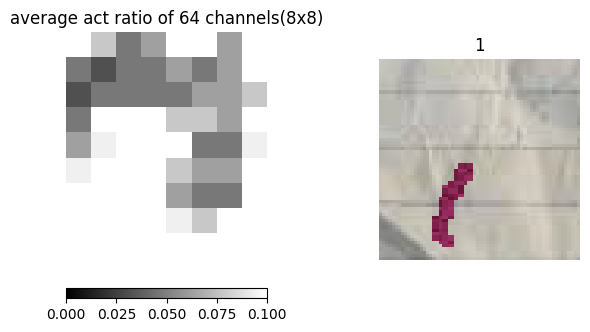

In [10]:
def filter_analysis(index):
    image = sample["image"][index]
    label = sample["label"][index]
    
    net.eval()
    with torch.no_grad():
        x = image.unsqueeze(0)
        x = net.pool(net.convblock0(x))
        x = net.pool(net.convblock1(x))
        x = net.pool(net.convblock2(x))
        filters = net.act(x)[0]
    net.train()
    
    # print(filters.shape)
    print((filters>0).float().sum())
    # print((filters>0).sum(0))
    # act = filters.view(8,-1,1)[:, 128:192, :]
    act_overview = (filters>0).sum(0, keepdim=True) / 64
    # act_overview_img = topil(act_overview.cpu())

    fig, ax = plt.subplots(1, 2)
    fig.tight_layout(pad=3.0, h_pad=2.0, w_pad=5.0)
    ax[0].set_title("average act ratio of 64 channels(8x8)")
    im = ax[0].imshow(act_overview.cpu().permute(1, 2, 0), vmin=0, vmax=0.1, cmap="gray")
    fig.colorbar(im, location="bottom")

    ax[1].imshow(topil(image))
    ax[1].set_title(label.item())

    ax[0].axis("off")
    ax[1].axis("off")
    plt.show()
    
filter_analysis(0)

tensor(497., device='mps:0')


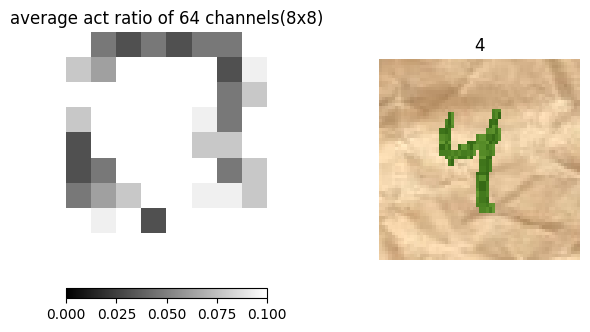

In [11]:
filter_analysis(10)

tensor(431., device='mps:0')


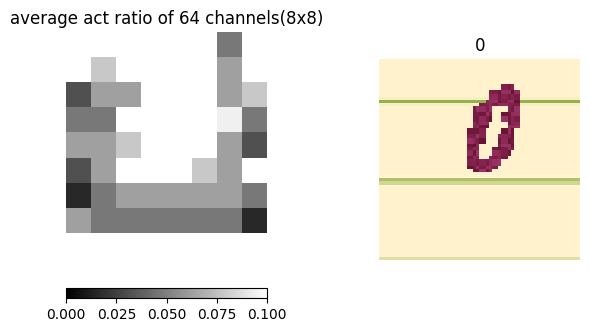

In [12]:
filter_analysis(20)

torch.Size([256, 8, 8])
tensor(129., device='mps:0')


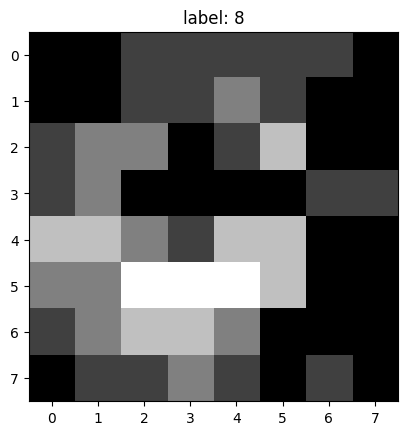

In [27]:
sample = next(iter(dataloader))
net.eval()
with torch.no_grad():
    x = sample["image"][0].unsqueeze(0)
    x = net.pool(net.convblock0(x))
    x = net.pool(net.convblock1(x))
    x = net.pool(net.act(net.convblock2(x)))
    filters = net.convblock3(x)[0]
net.train()

print(filters.shape)
print((filters>0).float().sum())
# print((filters>0).sum(0))
act = (filters>0).sum(0, keepdim=True) / 256
show(act, sample["label"][0])
# plt.imshow(filters[128].detach().cpu().numpy())

torch.Size([256, 8, 8])
tensor(119., device='mps:0')


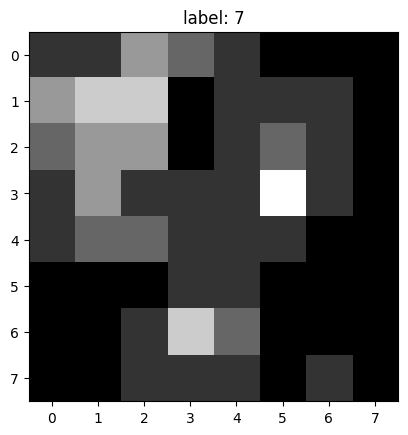

In [30]:
index = 1
sample = next(iter(dataloader))
x = sample["image"][index].unsqueeze(0)
label = sample["label"][index]
net.eval()
with torch.no_grad():
    x = net.pool(net.convblock0(x))
    x = net.pool(net.convblock1(x))
    x = net.pool(net.act(net.convblock2(x)))
    filters = net.convblock3(x)[0]
net.train()

print(filters.shape)
print((filters>0).float().sum())
# print((filters>0).sum(0))
act = (filters>0).sum(0, keepdim=True) / 256
show(act, label)
# plt.imshow(filters[128].detach().cpu().numpy())

### Use Big network to help Small network

- Big networks last filter activation shows the pixel significant in that position.
- Small networks got stuck into figure out this.
- How about Give it as special "tips" for small network?

-> ROI(region of interest) 데이터를 주지 않은 경우보다 val_acc가 낮게 나오는 경우도 있지만, linear net으로는.. 압도.

Val accuracy plot (with 주황: ROI 유 / 파랑: ROI 무)

![smallnet](./smallnet.png)

(-0.5, 63.5, 63.5, -0.5)

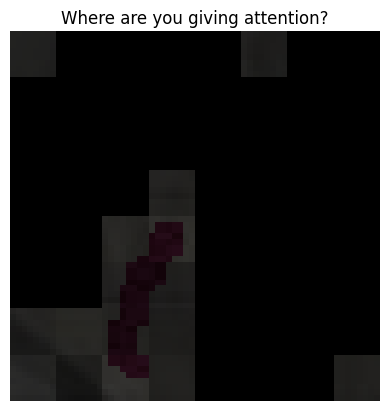

In [35]:
epsilon = 1.5e-1

def get_roi_map(images: torch.Tensor):
    net.eval()
    with torch.no_grad():
        x = images
        x = net.pool(net.convblock0(x))
        x = net.pool(net.convblock1(x))
        x = net.pool(net.convblock2(x))
        filters = net.act(x)
    net.train()

    total_act_by_pos = (filters>0).sum(1, keepdim=True) # 1x1x8x8
    #print(total_act_by_pos)
    #act_prob = total_act_by_pos.view(-1, 1, 64).softmax(2).view(-1, 1, 8, 8)
    #act_prob = total_act_by_pos - total_act_by_pos.max()
    #act_prob = -(total_act_by_pos / 64).log()
    act_prob = total_act_by_pos / 64
    act_prob[act_prob<epsilon] = 0
    #act_prob[act_prob>epsilon] *= 
    #torch.where(act_prob<0)
    #act_prob = act_prob.view(-1, 1, 64).softmax(2).view(-1, 1, 8, 8) * 64
    big_act_prob = F.interpolate(act_prob, size=[64, 64],  mode='nearest')
    return images * big_act_prob
    
roi_map = get_roi_map(sample["image"])

plt.title("Where are you giving attention?")
plt.imshow(roi_map.cpu()[0].permute(1, 2, 0))
plt.axis("off")

In [42]:
class SmallNetwork(nn.Module):
    def __init__(self): # 64 -> 32 -> 16 -> 8
        super().__init__()
        self.projection0 = nn.Linear(3*64*64, 512)
        self.projection1 = nn.Linear(512, 10)

        self.act = nn.ReLU()

    def forward(self, x, y=None):
        B = x.size(0)
        x = x.view(B, -1)
        x = self.projection0(x)
        x = self.act(x)
        x = self.projection1(x)
        loss = None
        if y is not None:
            loss = F.cross_entropy(x, y, reduction="mean")
        return x, loss

In [44]:
import time
from essential import exp_logger
import tqdm
snet = SmallNetwork().to(device)
lr = 0.001
optimizer = torch.optim.AdamW(snet.parameters(), lr=lr, weight_decay=0.01)

start = time.monotonic()
configs = exp_logger.BasicConfig(lr=lr, start=start, model_hp={}, model_script="", optimizer={"weight_decay": 0.01})
run = exp_logger.Logger(exp_logger.OFFLINE, run_name=f"small network with roi scaling", configs=configs)

max_epoch = 5

for epoch in range(max_epoch):
    loss_accum = 0
    total_acc = 0
    max_n = 0
    val_items = 0
    for n, batch in enumerate(tqdm.tqdm(dataloader)):
        images = batch["image"]
        #images = get_roi_map(images)
        labels = batch["label"]
        if n * batch_size > 60000: # 60000 train / 9000 val
            with torch.no_grad():
                snet.eval()
                y, _ = snet(images)
                total_acc += (y.argmax(-1)==labels).float().sum(0).item()
                val_items += labels.size(0) # B, _, _, _,
                continue
        else:
            snet.train()
            max_n = n+1
        y, loss = snet(images, labels)
        loss_accum += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    run.log({"train/loss": loss_accum/max_n, "val/acc": total_acc/val_items}, step=epoch)
    run.log_ckp(snet, epoch)
    if epoch+1 == max_epoch:
        run.save_ckp(snet, optimizer, f"epoch-{epoch}.pkl")

    print(f"epoch: {epoch} loss: {loss_accum/(max_n)} val acc: {total_acc/val_items}")

100%|█████████████████████████████████████████| 270/270 [00:07<00:00, 36.22it/s]


epoch: 0 loss: 2.570758303175581 val acc: 0.18371040723981902


100%|█████████████████████████████████████████| 270/270 [00:05<00:00, 50.12it/s]


epoch: 1 loss: 2.2251340571870197 val acc: 0.20316742081447964


100%|█████████████████████████████████████████| 270/270 [00:06<00:00, 44.93it/s]


epoch: 2 loss: 2.1799156838275016 val acc: 0.2167420814479638


100%|█████████████████████████████████████████| 270/270 [00:05<00:00, 48.22it/s]


epoch: 3 loss: 2.1462329093446124 val acc: 0.23857466063348418


100%|█████████████████████████████████████████| 270/270 [00:05<00:00, 47.94it/s]


epoch: 4 loss: 2.124734041538644 val acc: 0.23846153846153847


In [152]:
information_capacity = sum([p.nelement() for p in net.parameters()])
informations = 64*64*3 * 60000

print(f"Compression Ratio : {information_capacity/informations}") # how to make it more accurate?

Compression Ratio : 0.002999203830295139


In [155]:
import numpy as np
@torch.no_grad
def eval_function(network, batch_size=64):
    #features = Features({"image": Array3D(shape=(3, 64, 64), dtype='float32'), "label": ClassLabel(names=list(range(10)))}) # To avoid this, you must explicitly use the Array feature type and specify the shape of your tensors:
    #ds = load_dataset("yoonhero/difficult_mnist_2", num_proc=4, features=features) # download 시간이 조금 소요될 수 있습니다.
    #device = "mps" # 사용 가능한 accelerator 여부에 따라서 다음을 바꿔줍니다.
    #ds = ds.with_format("torch", device=device) # https://huggingface.co/docs/datasets/en/use_with_pytorch
    test_dataloader = DataLoader(ds["test"], batch_size=batch_size, shuffle=False)
    net.eval() # disable dropout(activates on train stage)
    sols = []
    for batch in tqdm.tqdm(test_dataloader):
        images = batch["image"]
        y, _ = network(images)
        sols += y.argmax(-1).tolist()
    net.train()

    return sols

with open("sol.txt", "r") as f:
    sols = [int(a) for a in f.readlines()]

print(f"You score {(np.array(sols) == np.array(eval_function(net))).sum()}")

100%|███████████████████████████████████████████| 16/16 [00:00<00:00, 61.50it/s]

You score 982
